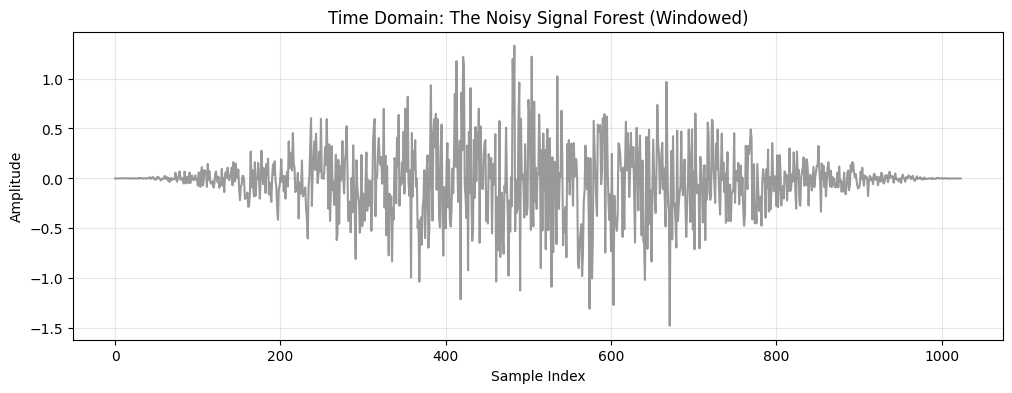

Goliath Amplitude: 0.2000
David Amplitude:   0.1000


In [97]:
import numpy as np
import matplotlib.pyplot as plt
from fft_utils import run_sim, analyze_fft_performance
# --- ACT 1: THE STATIC STORM ---
N = 1024
t = np.arange(N)

# Generate Goliath (High amplitude, low frequency)
goliath_freq = 30
goliath_amp = 0.2
goliath = goliath_amp * np.sin(2 * np.pi * goliath_freq * t / N)

# Generate David (Tiny amplitude, high frequency)
david_freq = 200
david_amp = 0.1 # -80 dB relative to Goliath
david = david_amp * np.sin(2 * np.pi * david_freq * t / N)

# MASSIVE NOISE (Amplitude 2.0, significantly larger than Goliath)
noise = 0.5 * np.random.randn(N) 

storm_signal = (goliath + david + noise) * np.hanning(N)

plt.figure(figsize=(12, 4))
plt.plot(t, storm_signal, color='gray', alpha=0.8)
plt.title("Time Domain: The Noisy Signal Forest (Windowed)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Goliath Amplitude: {goliath_amp:.4f}")
print(f"David Amplitude:   {david_amp:.4f}")

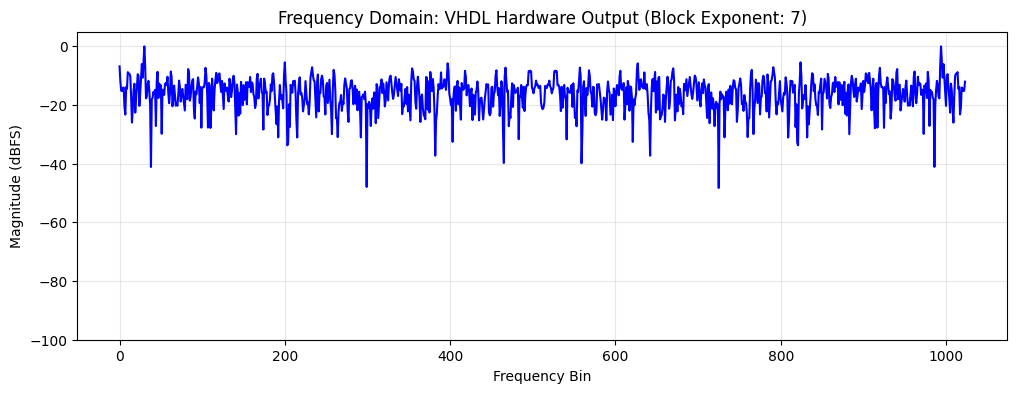

In [98]:
# --- ACT 2: THE FFT REVEAL ---
fft_hw, e1, _ = run_sim(storm_signal, invert=False)

# Normalize for plotting (ignore those -240dB spikes by setting a floor)
mag_db = 20 * np.log10(np.abs(fft_hw) / np.max(np.abs(fft_hw)) + 1e-10) 
mag_db = np.clip(mag_db, -100, 0) # This hides the -240dB "perfect zeros" for a cleaner plot

# Plot the Frequency Domain
plt.figure(figsize=(12, 4))
plt.plot(mag_db, 'b-', linewidth=1.5)
plt.title(f"Frequency Domain: VHDL Hardware Output (Block Exponent: {e1})")
plt.xlabel("Frequency Bin")
plt.ylabel("Magnitude (dBFS)")
plt.ylim([-100, 5])
plt.grid(True, alpha=0.3)

plt.show()

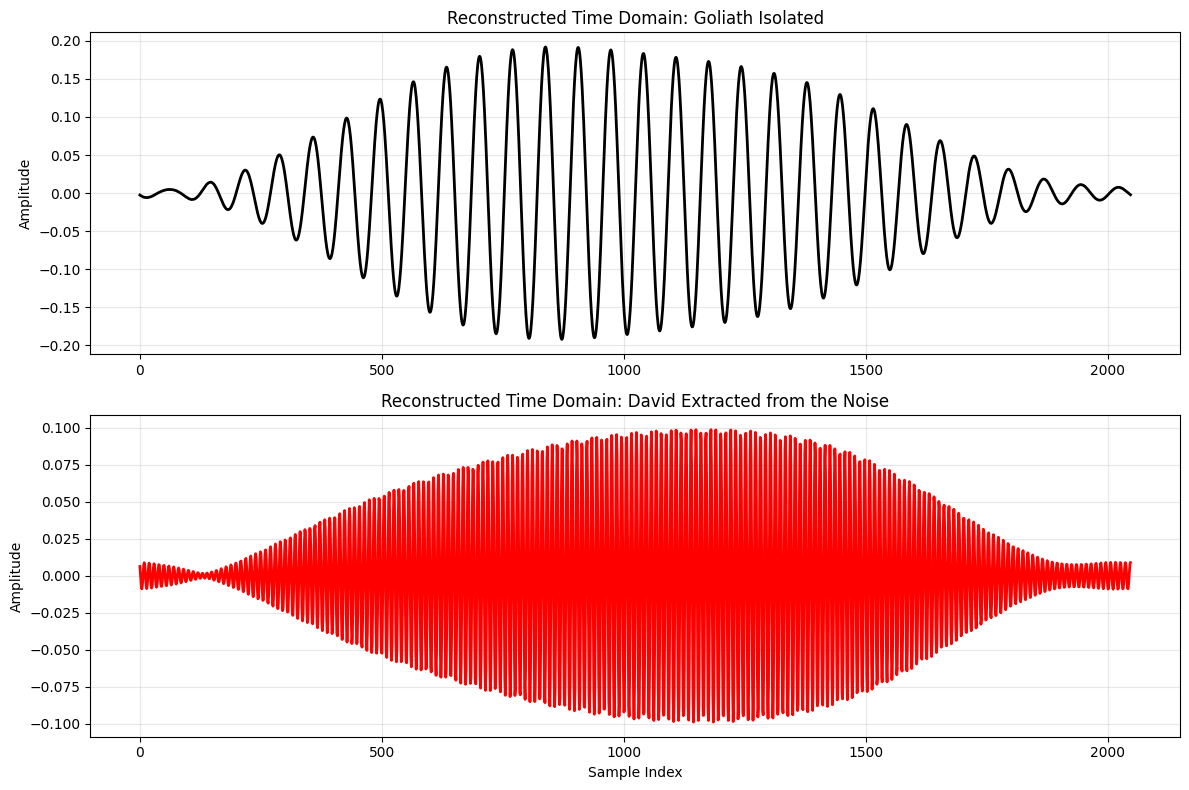

In [76]:
# Create empty arrays for our isolated signals
fft_goliath = np.zeros_like(fft_hw)
fft_david = np.zeros_like(fft_hw)

# Isolate Goliath (Bin 30 and its Nyquist mirror)
fft_goliath[goliath_freq-2 : goliath_freq+3] = fft_hw[goliath_freq-2 : goliath_freq+3]
fft_goliath[N-goliath_freq-2 : N-goliath_freq+3] = fft_hw[N-goliath_freq-2 : N-goliath_freq+3]

# Isolate David (Bin 200 and its Nyquist mirror)
fft_david[david_freq-2 : david_freq+3] = fft_hw[david_freq-2 : david_freq+3]
fft_david[N-david_freq-2 : N-david_freq+3] = fft_hw[N-david_freq-2 : N-david_freq+3]

# --- Step 2: Inverse FFT through VHDL ---
recon_goliath, e2_g, _ = run_sim(fft_goliath, invert=True)
recon_david, e2_d, _ = run_sim(fft_david, invert=True)

# Apply scaling equation to restore actual amplitudes
final_goliath = (recon_goliath.real * (2.0**(e1 + e2_g))) / N
final_david = (recon_david.real * (2.0**(e1 + e2_d))) / N

# Plot the Reconstructed Time Domain Signals
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Goliath Plot
ax1.plot(t, final_goliath, 'k-', linewidth=2)
ax1.set_title("Reconstructed Time Domain: Goliath Isolated")
ax1.set_ylabel("Amplitude")
ax1.grid(True, alpha=0.3)

# David Plot (Notice the y-axis scale!)
ax2.plot(t, final_david, 'r-', linewidth=2)
ax2.set_title("Reconstructed Time Domain: David Extracted from the Noise")
ax2.set_xlabel("Sample Index")
ax2.set_ylabel("Amplitude")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()